# Tech Challenge - Fase 2

**Desafio:** Criar um modelo que preveja se o fechamento do IBOVESPA do dia
seguinte será maior ou menor que o do dia atual.

**Objetivo:** O modelo deve prever a tendência (↑ ou ↓) com acuracidade mínima
de 75% em um conjunto de teste. O conjunto de testes deverá conter o último
mês (30 dias) de dados disponíveis.

#### Instalação das libs

In [178]:
!pip install joblib optuna

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import joblib
from sklearn.model_selection import cross_val_score
import optuna # Otimização de Hiperparâmetros

In [179]:
# Configurações de display e warnings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

df_ibovespa = pd.read_csv("/content/IbovDef.csv")

### Entendimento e tratamento dos dados

In [180]:
df_ibovespa.columns = df_ibovespa.columns.str.strip() # Limpar nomes de colunas
df_ibovespa.rename(columns={'Vol.': 'Volume', 'Var%': 'Variacao'}, inplace=True) # Padronizar nomes

df_ibovespa['Data'] = pd.to_datetime(df_ibovespa['Data'], format='%d.%m.%Y', dayfirst=True, errors='coerce')
df_ibovespa.set_index('Data', inplace=True)
df_ibovespa.sort_index(ascending=True, inplace=True)

**Obervação:** Transformar a coluna data como índice garante a coerência de série temporal, sendo essencial para evitar data leakage no cálculo das features temporais (.shift e .rolling).

In [181]:
df_ibovespa.head()

,Último,Abertura,Máxima,Mínima,Volume,Variacao
Data,,,,,,
2000-01-03,16.930,17.098,17.408,16.719,"777,29M","-0,95%"
2000-01-04,15.851,16.908,16.908,15.851,"102,42M","-6,37%"
2000-01-05,16.245,15.871,16.302,15.350,"112,10M","2,49%"
2000-01-06,16.107,16.237,16.499,15.977,"105,25M","-0,85%"
2000-01-07,16.309,16.125,16.449,16.125,"633,18M","1,25%"


In [182]:
df_ibovespa.tail()

,Último,Abertura,Máxima,Mínima,Volume,Variacao
Data,,,,,,
2025-10-01,145.517,146.237,146.879,145.193,"8,34B","-0,49%"
2025-10-02,143.950,145.517,145.621,143.635,"7,25B","-1,08%"
2025-10-03,144.201,143.950,144.518,143.676,"6,18B","0,17%"
2025-10-06,143.608,144.202,144.532,143.376,"5,98B","-0,41%"
2025-10-07,141.356,143.606,143.606,141.035,"9,27B","-1,57%"


In [183]:
df_ibovespa.shape

(6388, 6)

In [184]:
df_ibovespa.isnull().sum()

,0
Último,0
Abertura,0
Máxima,0
Mínima,0
Volume,1
Variacao,0


In [185]:
df_ibovespa.dropna(subset=['Volume'], inplace=True)

**Observação:** Remover o valor nulo na coluna de Volume é uma boa prática de limpeza de dados. Como o dataset contém 6388 registyros, a exclusão de uma única linha é insignificante e evita a necessidade de imputar um valor (como a média), o que poderia poluir sutilmente o dataset.

In [186]:
df_ibovespa.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6387 entries, 2000-01-03 to 2025-10-07
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Último    6387 non-null   float64
 1   Abertura  6387 non-null   float64
 2   Máxima    6387 non-null   float64
 3   Mínima    6387 non-null   float64
 4   Volume    6387 non-null   object 
 5   Variacao  6387 non-null   object 
dtypes: float64(4), object(2)
memory usage: 349.3+ KB


In [187]:
#Conferindo as letras que a coluna volume têm
df_ibovespa['Volume'].str[-1].unique()

array(['M', 'K', 'B'], dtype=object)

In [188]:
#Função para converter a coluna volume para o valor correto

def converter_volume_robust(vol_str):
    vol_str = str(vol_str).strip().upper()

    multiplicador = 1.0
    if vol_str.endswith('B'): multiplicador = 1e9; vol_str = vol_str[:-1]
    elif vol_str.endswith('M'): multiplicador = 1e6; vol_str = vol_str[:-1]
    elif vol_str.endswith('K'): multiplicador = 1e3; vol_str = vol_str[:-1]

    try:
        # A limpeza do ponto é crítica: se o formato for 1.000,00, removemos o milhar.
        numeric_str = vol_str.replace('.', '').replace(',', '.')
        return float(numeric_str) * multiplicador
    except ValueError:
        return np.nan

# Aplicar a função de Volume e criar Volume Absoluto
df_ibovespa['Volume_Absoluto'] = df_ibovespa['Volume'].apply(converter_volume_robust)


In [189]:
# Limpar e converter a coluna Variação para PROPORÇÃO DECIMAL
df_ibovespa['Var_proporcao'] = (
    df_ibovespa['Variacao'].astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
).astype(float) / 100

# df_ibovespa.drop(columns=['Volume', 'Variacao'], inplace=True)

**Observação:** Converter a coluna de Variação para proporção é uma boa prática segundo a metodologia de ML financeiro, pois padroniza o retorno no formato decimal correto e otimiza a forma como os modelos lidam com a escala e a magnitude do sinal preditivo.

In [190]:
df_ibovespa.head()

,Último,Abertura,Máxima,Mínima,Volume,Variacao,Volume_Absoluto,Var_proporcao
Data,,,,,,,,
2000-01-03,16.930,17.098,17.408,16.719,"777,29M","-0,95%",777290000.0,-0.0095
2000-01-04,15.851,16.908,16.908,15.851,"102,42M","-6,37%",102420000.0,-0.0637
2000-01-05,16.245,15.871,16.302,15.350,"112,10M","2,49%",112100000.0,0.0249
2000-01-06,16.107,16.237,16.499,15.977,"105,25M","-0,85%",105250000.0,-0.0085
2000-01-07,16.309,16.125,16.449,16.125,"633,18M","1,25%",633180000.0,0.0125


### Análise exploratória

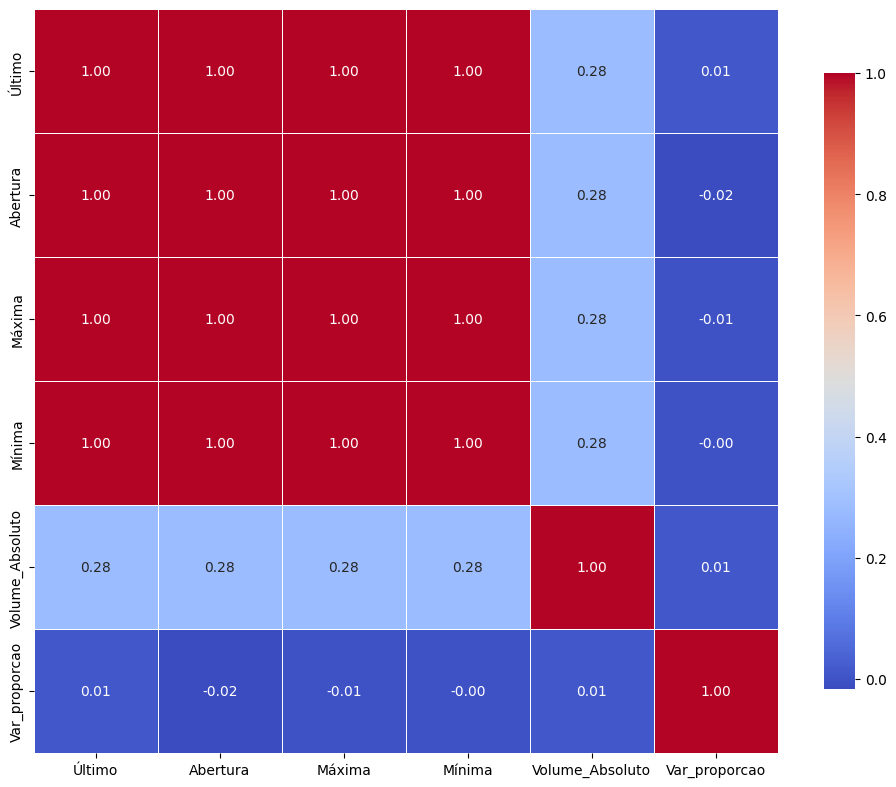

In [191]:
# Select only numeric columns for correlation matrix
df_ibovespa_numeric = df_ibovespa.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = df_ibovespa_numeric.corr()

plt.figure(figsize=(12,10))

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})

plt.show()

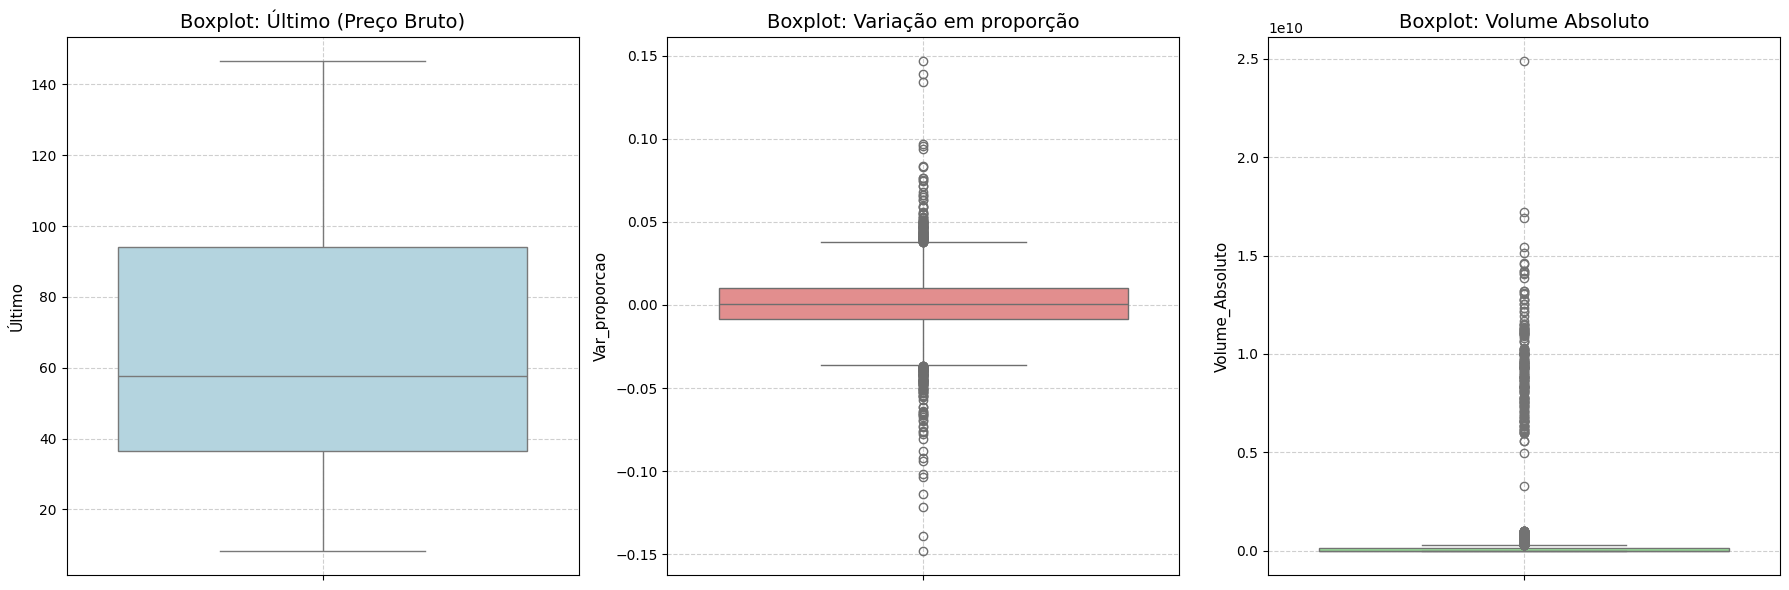

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Boxplot: Preço (Último)
sns.boxplot(
    y=df_ibovespa['Último'],
    color='lightblue',
    ax=axes[0], # Direciona para o primeiro gráfico
    whis=1.5
)
axes[0].set_title('Boxplot: Último (Preço Bruto)', fontsize=14)
axes[0].set_ylabel("Último", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)


# 2. Boxplot: Retorno (Var_proporcao)
sns.boxplot(
    y=df_ibovespa['Var_proporcao'],
    color='lightcoral',
    ax=axes[1], # Direciona para o segundo gráfico
    whis=1.5
)
axes[1].set_title('Boxplot: Variação em proporção', fontsize=14)
axes[1].set_ylabel("Var_proporcao", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)


# 3. Boxplot: Volume Transformado (Volume_Absoluto)
sns.boxplot(
    y=df_ibovespa['Volume_Absoluto'],
    color='lightgreen',
    ax=axes[2], # Direciona para o terceiro gráfico
    whis=1.5
)
axes[2].set_title('Boxplot: Volume Absoluto', fontsize=14)
axes[2].set_ylabel("Volume_Absoluto", fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)


# 3. Ajustar o layout
plt.tight_layout()
plt.show()

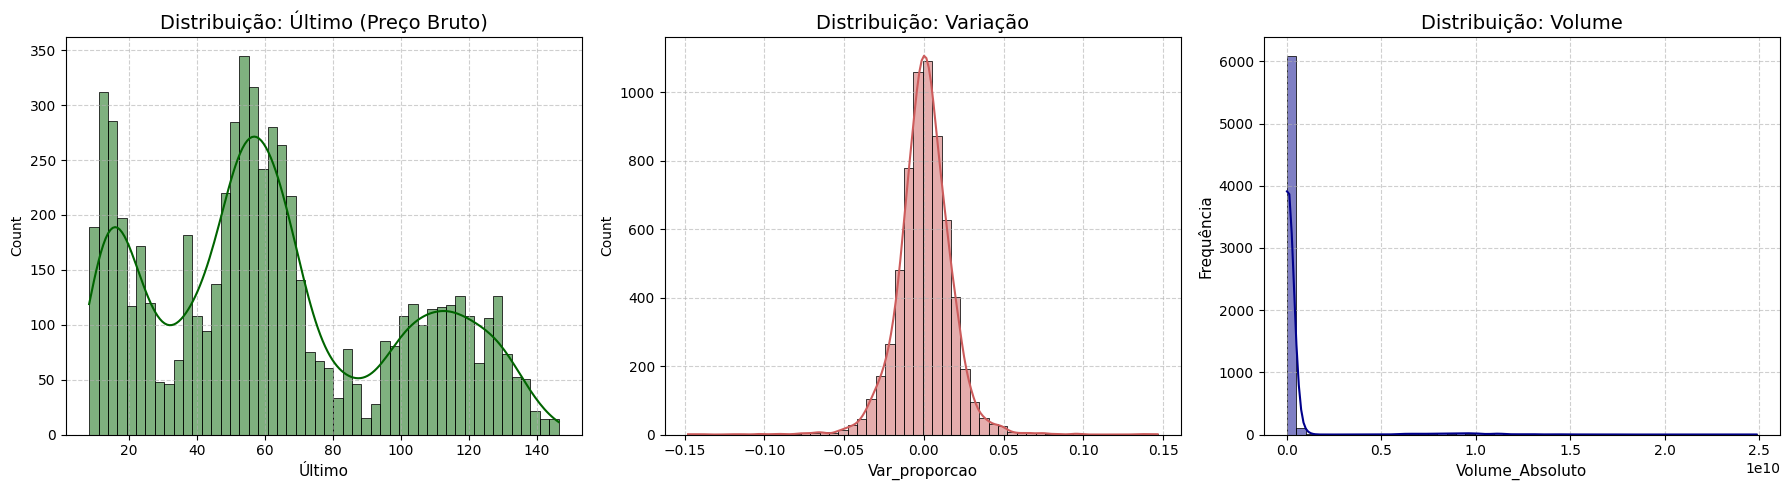

In [193]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma: Preço (Último)
sns.histplot(
    df_ibovespa['Último'],
    bins=50,
    kde=True,
    color='darkgreen',
    ax=axes[0] # Direciona para o primeiro gráfico
)
axes[0].set_title('Distribuição: Último (Preço Bruto)', fontsize=14)
axes[0].set_xlabel('Último', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)


# Histograma: Retorno (Retorno_Diario)
sns.histplot(
    df_ibovespa['Var_proporcao'],
    bins=50,
    kde=True,
    color='indianred',
    ax=axes[1] # Direciona para o segundo gráfico
)
axes[1].set_title('Distribuição: Variação', fontsize=14)
axes[1].set_xlabel('Var_proporcao', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)


# Histograma: Volume Transformado (Volume_log)
sns.histplot(
    df_ibovespa['Volume_Absoluto'],
    bins=50,
    kde=True,
    color='darkblue',
    ax=axes[2] # Direciona para o terceiro gráfico
)
axes[2].set_title('Distribuição: Volume', fontsize=14)
axes[2].set_xlabel('Volume_Absoluto', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].set_ylabel("Frequência", fontsize=11) # Adiciona rótulo Y no último gráfico (ou no primeiro)


# Ajustar o layout
plt.tight_layout()
plt.show()

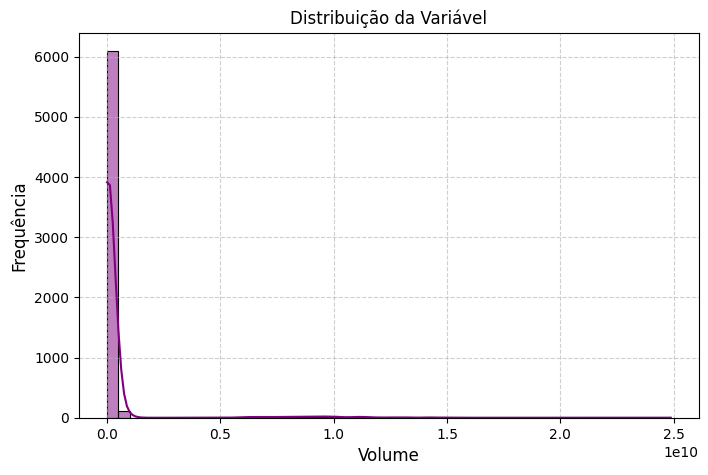

In [194]:
plt.figure(figsize=(8, 5))
# Use seaborn.histplot instead of matplotlib.pyplot.hist for KDE overlay
sns.histplot(df_ibovespa['Volume_Absoluto'], bins=50, kde=True, color='purple')
plt.title("Distribuição da Variável")
plt.xlabel('Volume', fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Observação:** A coluna de volume após o tratamento apresenta uma grande concentração dos valores em um único ponto do eixo X e o Boxplot acima também apresentam muitos outliers extremos que podem enviesar o modelo. Segundo pesquisas e as melhores práticas de ML, nesse cenário a melhor opção é aplicar uma transformação logaritimica, esta técnica reduz o impacto desses extremos e torna a feature mais simétrica, o que melhora a eficiência e a capacidade de generalização dos modelos.

In [195]:
# Criar a feature Volume Logarítmico
df_ibovespa['Volume_log'] = np.log1p(df_ibovespa['Volume_Absoluto'])


In [196]:
df_ibovespa.head()

,Último,Abertura,Máxima,Mínima,Volume,Variacao,Volume_Absoluto,Var_proporcao,Volume_log
Data,,,,,,,,,
2000-01-03,16.930,17.098,17.408,16.719,"777,29M","-0,95%",777290000.0,-0.0095,20.471324
2000-01-04,15.851,16.908,16.908,15.851,"102,42M","-6,37%",102420000.0,-0.0637,18.444593
2000-01-05,16.245,15.871,16.302,15.350,"112,10M","2,49%",112100000.0,0.0249,18.534902
2000-01-06,16.107,16.237,16.499,15.977,"105,25M","-0,85%",105250000.0,-0.0085,18.471849
2000-01-07,16.309,16.125,16.449,16.125,"633,18M","1,25%",633180000.0,0.0125,20.266265


In [197]:
df_ibovespa.describe()

,Último,Abertura,Máxima,Mínima,Volume_Absoluto,Var_proporcao,Volume_log
count,6387.000000,6387.000000,6387.000000,6387.000000,6.387000e+03,6387.000000,6387.000000
mean,63.052052,63.033795,63.638293,62.441008,3.540243e+08,0.000477,16.625054
std,36.223860,36.214222,36.453452,35.985514,1.659780e+09,0.017067,2.164031
min,8.371000,8.397000,8.513000,8.225000,1.121000e+05,-0.147800,11.627156
25%,36.578000,36.560000,37.216500,36.186000,3.230000e+06,-0.008600,14.987993
50%,57.647000,57.644000,58.138000,57.109000,8.000000e+06,0.000600,15.894952
75%,93.984000,93.940000,94.954500,93.292500,1.261450e+08,0.009950,18.652943
max,146.492000,146.492000,147.578000,146.067000,2.487000e+10,0.146600,23.936928


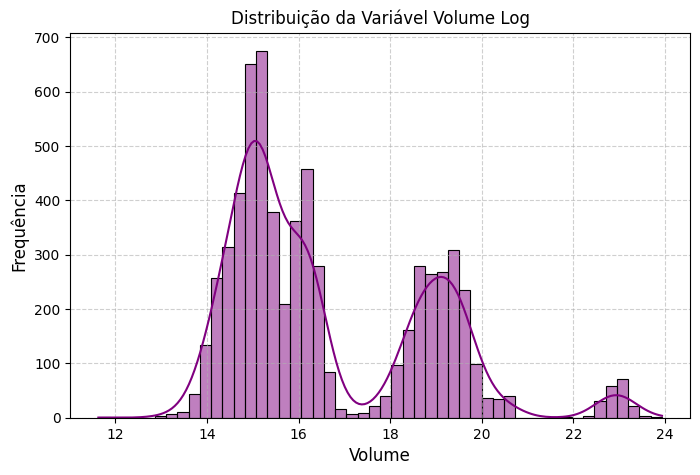

In [198]:
plt.figure(figsize=(8, 5))
# Use seaborn.histplot instead of matplotlib.pyplot.hist for KDE overlay
sns.histplot(df_ibovespa['Volume_log'], bins=50, kde=True, color='purple')
plt.title("Distribuição da Variável Volume Log")
plt.xlabel('Volume', fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

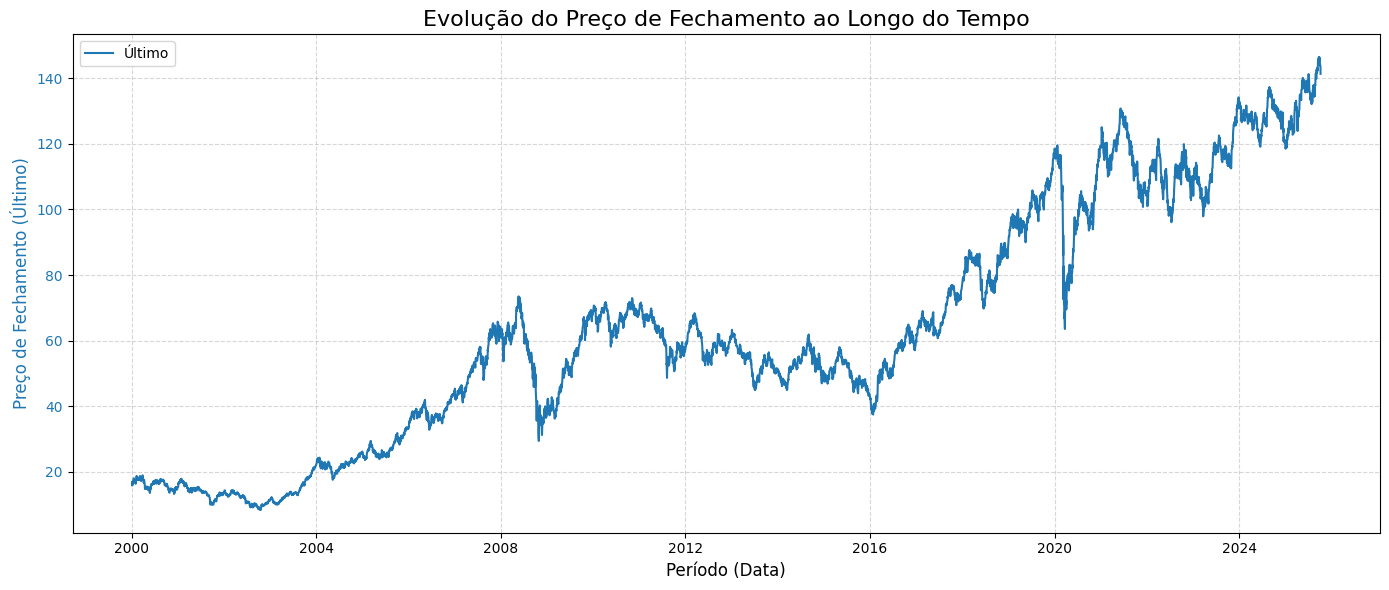

In [199]:
plt.figure(figsize=(14, 6))

color_preco = 'tab:blue'
plt.xlabel('Período (Data)', fontsize=12)
plt.ylabel('Preço de Fechamento (Último)', color=color_preco, fontsize=12)
plt.plot(df_ibovespa.index, df_ibovespa['Último'], color=color_preco, label='Último', linewidth=1.5)
plt.tick_params(axis='y', labelcolor=color_preco)
plt.grid(True, linestyle='--', alpha=0.5)

plt.title('Evolução do Preço de Fechamento ao Longo do Tempo', fontsize=16)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

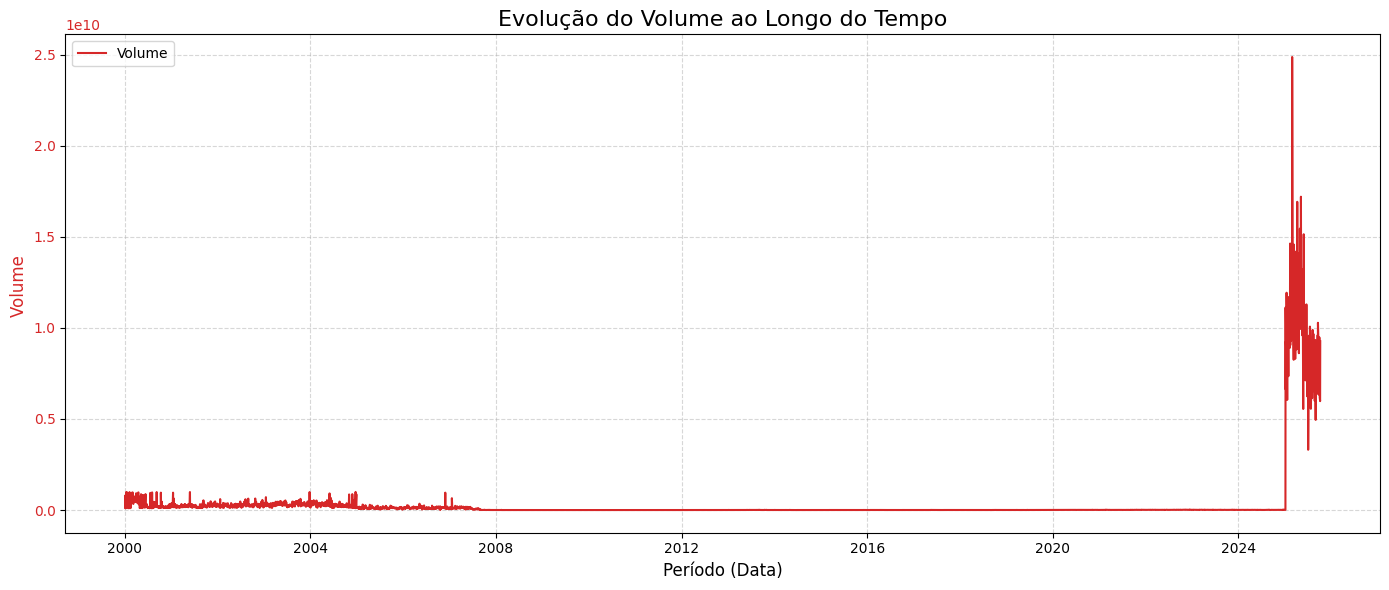

In [200]:
plt.figure(figsize=(14, 6))

color_volume = 'tab:red'
plt.xlabel('Período (Data)', fontsize=12)
plt.ylabel('Volume ', color=color_volume, fontsize=12)
plt.plot(df_ibovespa.index, df_ibovespa['Volume_Absoluto'], color=color_volume, label='Volume', linewidth=1.5)
plt.tick_params(axis='y', labelcolor=color_volume)
plt.grid(True, linestyle='--', alpha=0.5)

plt.title('Evolução do Volume ao Longo do Tempo', fontsize=16)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Criando Features Derivadas

In [201]:
# TENDÊNCIA / MOMENTO
df_ibovespa['retorno_pct'] = (df_ibovespa['Último'] - df_ibovespa['Abertura']) / df_ibovespa['Abertura'] * 100
df_ibovespa['retorno_1d'] = df_ibovespa['Var_proporcao'] * 100 # Retorno diário em %
df_ibovespa['EMA_5D'] = df_ibovespa['Último'].ewm(span=5, adjust=False).mean()
df_ibovespa['EMA_20D'] = df_ibovespa['Último'].ewm(span=20, adjust=False).mean()
df_ibovespa['Gap_EMA_Pct'] = (df_ibovespa['EMA_5D'] - df_ibovespa['EMA_20D']) / df_ibovespa['EMA_20D'] * 100

# VOLATILIDADE / RISCO
df_ibovespa['Amplitude_Pct'] = (df_ibovespa['Máxima'] - df_ibovespa['Mínima']) / df_ibovespa['Abertura'] * 100
df_ibovespa['Vol_Retorno_5D'] = df_ibovespa['Var_proporcao'].rolling(window=5).std()
df_ibovespa['Vol_Retorno_20D'] = df_ibovespa['Var_proporcao'].rolling(window=20).std()

# ATR (Average True Range)
df_ibovespa['TR1'] = df_ibovespa['Máxima'] - df_ibovespa['Mínima']
df_ibovespa['TR2'] = (df_ibovespa['Máxima'] - df_ibovespa['Último'].shift(1)).abs()
df_ibovespa['TR3'] = (df_ibovespa['Mínima'] - df_ibovespa['Último'].shift(1)).abs()
df_ibovespa['True_Range'] = df_ibovespa[['TR1', 'TR2', 'TR3']].max(axis=1)
df_ibovespa['ATR_14D'] = df_ibovespa['True_Range'].rolling(14).mean()

# LIQUIDEZ / VOLUME
df_ibovespa['Volume_MA_5D'] = df_ibovespa['Volume_Absoluto'].rolling(window=5).mean()
df_ibovespa['Volume_Ratio'] = df_ibovespa['Volume_Absoluto'] / df_ibovespa['Volume_MA_5D']
# Volume_log já existe

#  INTERATIVIDADE / CORRELAÇÃO
df_ibovespa['Momentum_Liquidez'] = df_ibovespa['Var_proporcao'].shift(1) * df_ibovespa['Volume_Ratio']
df_ibovespa['Tendencia_Forca'] = df_ibovespa['Var_proporcao'] * df_ibovespa['EMA_5D'] # Variante autoral, usa sinal e tendência

#  CRIAÇÃO DO TARGET SIMPLES
df_ibovespa['Fechamento_Amanha_Target'] = df_ibovespa['Último'].shift(-1)
df_ibovespa['Target'] = (df_ibovespa['Fechamento_Amanha_Target'] > df_ibovespa['Último']).astype(int)


**Descrição e Justificativa das Features Derivadas:**

As 13 Features foram selecionadas para fornecer aos modelos quatro perspectivas fundamentais do mercado: **Tendência, Volatilidade, Liquidez e Interação**

**Tendência e Momentum:** Estas Features mostram a direção atual e a força do movimento do preço.

**retorno_pct e retorno_1d:** Retorno Diário Simples. Medem o quanto o preço se moveu dentro do dia (abertura vs. fechamento) e de ontem (comparação simples).

**EMA_5D e EMA_20D:** Tendência Suavizada (Exponencial). As médias móveis exponenciais (EMA) dão mais peso aos dados recentes, revelando a direção atual (5D) e de longo prazo (20D).

**Gap_EMA_Pct:** Aceleração da Tendência. Mede o gap percentual entre a EMA de 5 dias e a EMA de 20 dias. Um gap crescente sugere que a tendência está acelerando (forte momentum)

**Volatilidade e Risco:** Estas Features quantificam o nível de incerteza e o risco do mercado.

**Amplitude_Pct:** Volatilidade Intraday. Mede a distância percentual entre a Máxima e a Mínima do dia em relação à Abertura. É um sinal direto do pânico ou euforia do dia.

**Vol_Retorno_5D e Vol_Retorno_20D:** Risco de Curto/Médio Prazo. São o desvio padrão dos retornos. Medem a volatilidade real do mercado, ajudando o modelo a entender o "clima" atual (nervoso ou calmo).

**ATR_14D:** Volatilidade Não-Direcional. O Average True Range é uma medida padrão da "verdadeira" volatilidade do mercado em 14 dias. É crucial para diagnosticar se o preço está em um movimento extremo.

**Liquidez e Volume:** Estas Features medem a pressão de compra/venda e o interesse do mercado.

**Volume_log:** Liquidez (Normalizada). O volume de negociação transformado logaritmicamente para remover a distorção exponencial dos outliers.

**Volume_Ratio:** Pressão de Volume. Compara o volume de hoje com o volume médio dos últimos 5 dias. Um valor > 1 sugere pressão de compra/venda incomum.

**Interatividade e Correlação:** Estas Features combinam diferentes sinais para criar indicadores de segunda ordem.

**Momentum_Liquidez:** Sinal de Continuação. Multiplica o retorno de ontem (Lag 1) pelo Volume Ratio. Se o mercado subiu ontem com volume acima da média, é um forte sinal de continuação da tendência (Alta).

**Tendencia_Forca:** Força Direcional da Tendência. Combina o Retorno do dia com a EMA de 5 dias. Ajuda o modelo a entender se um pequeno retorno (sinal) está ocorrendo em uma tendência já estabelecida (força).

In [202]:
df_ibovespa.head()

,Último,Abertura,Máxima,Mínima,Volume,Variacao,Volume_Absoluto,Var_proporcao,Volume_log,retorno_pct,retorno_1d,EMA_5D,EMA_20D,Gap_EMA_Pct,Amplitude_Pct,Vol_Retorno_5D,Vol_Retorno_20D,TR1,TR2,TR3,True_Range,ATR_14D,Volume_MA_5D,Volume_Ratio,Momentum_Liquidez,Tendencia_Forca,Fechamento_Amanha_Target,Target
Data,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2000-01-03,16.930,17.098,17.408,16.719,"777,29M","-0,95%",777290000.0,-0.0095,20.471324,-0.982571,-0.95,16.930000,16.930000,0.000000,4.029711,NaN,NaN,0.689,NaN,NaN,0.689,NaN,NaN,NaN,NaN,-0.160835,15.851,0
2000-01-04,15.851,16.908,16.908,15.851,"102,42M","-6,37%",102420000.0,-0.0637,18.444593,-6.251479,-6.37,16.570333,16.827238,-1.526720,6.251479,NaN,NaN,1.057,0.022,1.079,1.079,NaN,NaN,NaN,NaN,-1.055530,16.245,1
2000-01-05,16.245,15.871,16.302,15.350,"112,10M","2,49%",112100000.0,0.0249,18.534902,2.356499,2.49,16.461889,16.771787,-1.847734,5.998362,NaN,NaN,0.952,0.451,0.501,0.952,NaN,NaN,NaN,NaN,0.409901,16.107,0
2000-01-06,16.107,16.237,16.499,15.977,"105,25M","-0,85%",105250000.0,-0.0085,18.471849,-0.800641,-0.85,16.343593,16.708474,-2.183809,3.214880,NaN,NaN,0.522,0.254,0.268,0.522,NaN,NaN,NaN,NaN,-0.138921,16.309,1
2000-01-07,16.309,16.125,16.449,16.125,"633,18M","1,25%",633180000.0,0.0125,20.266265,1.141085,1.25,16.332062,16.670429,-2.029744,2.009302,0.033926,NaN,0.324,0.342,0.018,0.342,NaN,346048000.0,1.829746,-0.015553,0.204151,17.022,1


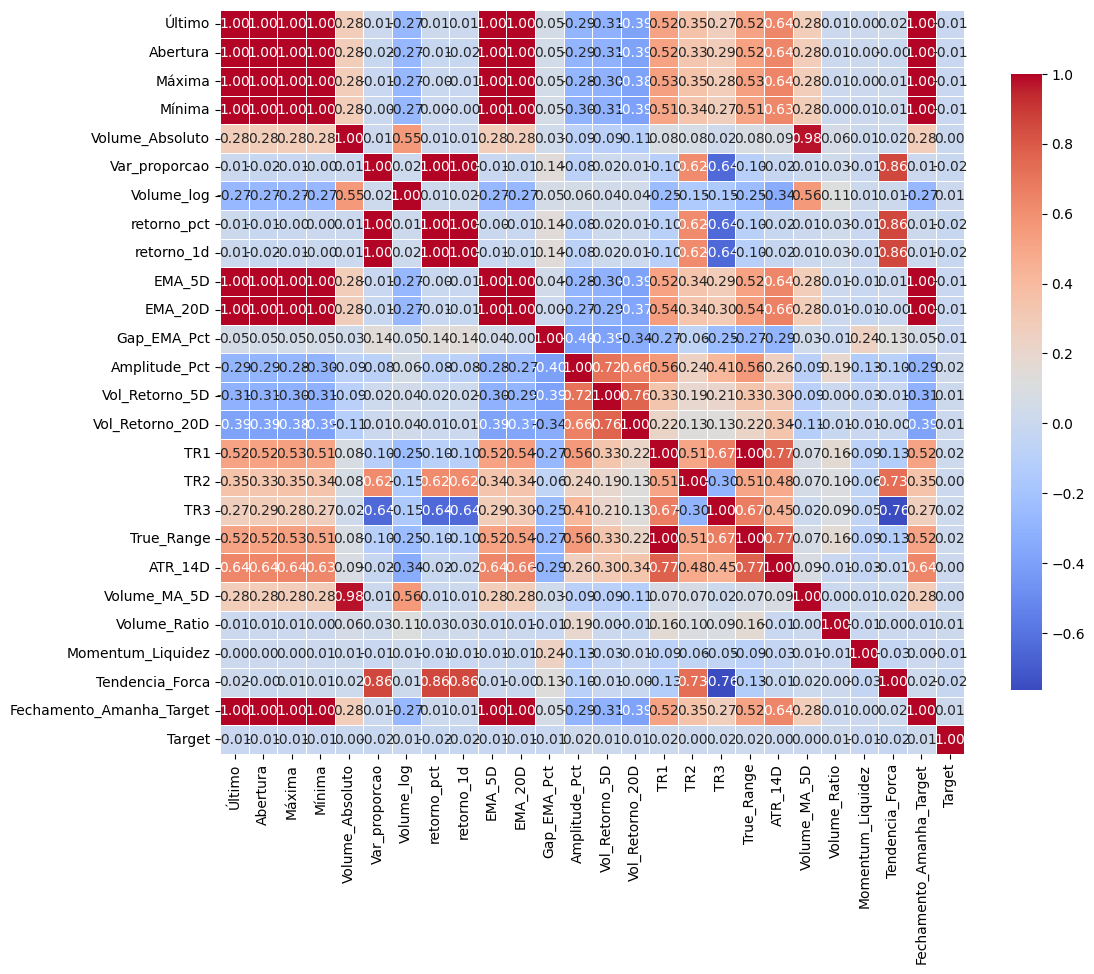

In [203]:
# Select only numeric columns for correlation matrix
df_ibovespa_numeric = df_ibovespa.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = df_ibovespa_numeric.corr()

plt.figure(figsize=(12,10))

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})

plt.show()

In [204]:
# DEFINIÇÃO FINAL DAS FEATURES E LIMPEZA
FEATURES = [
    'retorno_pct', 'retorno_1d', 'EMA_5D', 'EMA_20D', 'Gap_EMA_Pct',
    'Amplitude_Pct', 'Vol_Retorno_5D', 'Vol_Retorno_20D', 'ATR_14D',
    'Volume_log', 'Volume_Ratio', 'Momentum_Liquidez', 'Tendencia_Forca'
]
TARGET = 'Target'

# Remover colunas auxiliares que não serão features finais nem o target (e causam NaN)
colunas_auxiliares_remover = [
    'Fechamento_Amanha_Target', 'Volume_Absoluto', 'Var_proporcao',
    'TR1', 'TR2', 'TR3', 'True_Range', 'Volume_MA_5D'
]

df_ibovespa.drop(columns=[c for c in colunas_auxiliares_remover if c in df_ibovespa.columns], errors='ignore', inplace=True)

df_ibovespa_final = df_ibovespa.dropna(subset=FEATURES + [TARGET]).copy()

### Separação dos dados em treino e teste

In [205]:
TAMANHO_TESTE = 30
split_point = len(df_ibovespa_final) - TAMANHO_TESTE

X = df_ibovespa_final[FEATURES]
y = df_ibovespa_final[TARGET]

# Divisão Temporal (Holdout): Separa as features .iloc em treino (dados mais antigos) e teste (os 30 dias mais recentes).
# Rigor Anti-Leakage: O uso de .iloc garante que a ordem cronológica seja preservada, evitando que o modelo veja dados futuros durante o treinamento

X_train_raw = X.iloc[:split_point].copy()
X_test_raw = X.iloc[split_point:].copy()

y_train = y.iloc[:split_point].copy()
y_test = y.iloc[split_point:].copy()


# Escalonamento (fit no treino)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Converte os arrays NumPy resultantes do escalonamento de volta para DataFrames.

X_train = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_scaled, columns=FEATURES, index=X_test_raw.index)

print("--- DIAGNÓSTICO DO SPLIT E ESCALONAMENTO ---")
print(f"Total de Treino (dias): {len(X_train)}")
print(f"Total de Teste (dias): {len(X_test)}")
print(f"Balanceamento Teste (Alta): {y_test.mean():.2%}")

--- DIAGNÓSTICO DO SPLIT E ESCALONAMENTO ---
Total de Treino (dias): 6338
Total de Teste (dias): 30
Balanceamento Teste (Alta): 50.00%


### Regressão logistica

In [206]:
print("\n--- 1. REGRESSÃO LOGÍSTICA (BASELINE LINEAR) ---")
# Logistic Regression requer dados escalonados e é sensível à escala.
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

# Métrica de Teste
acc_test_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Acurácia de Teste (LogReg): {acc_test_logreg:.2%}")
print("\nRelatório de Classificação (LogReg TESTE):")
print(classification_report(y_test, y_pred_logreg))





--- 1. REGRESSÃO LOGÍSTICA (BASELINE LINEAR) ---
Acurácia de Teste (LogReg): 43.33%

Relatório de Classificação (LogReg TESTE):
              precision    recall  f1-score   support

           0       0.45      0.67      0.54        15
           1       0.38      0.20      0.26        15

    accuracy                           0.43        30
   macro avg       0.41      0.43      0.40        30
weighted avg       0.41      0.43      0.40        30



### Random Forest

In [207]:

print("\n--- 2. RANDOM FOREST CLASSIFIER---")
# Configuração moderada e regularizada para evitar o overfitting extremo visto anteriormente.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,          # Profundidade limitada para controlar overfitting
    min_samples_leaf=5,    # Regularização
    class_weight='balanced', # Tratar o desbalanceamento
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_train = rf_model.predict(X_train) # Para diagnóstico de overfitting

# Métrica de Teste
acc_test_rf = accuracy_score(y_test, y_pred_rf)
acc_train_rf = accuracy_score(y_train, y_pred_rf_train)

print(f"Acurácia de Treino (RF): {acc_train_rf:.2%}")
print(f"Acurácia de Teste (RF): {acc_test_rf:.2%}")
print(f"Overfitting/Generalização (Diferença): {acc_train_rf - acc_test_rf:.2%}")
print("\nRelatório de Classificação (RF TESTE):")
print(classification_report(y_test, y_pred_rf))


--- 2. RANDOM FOREST CLASSIFIER---
Acurácia de Treino (RF): 93.75%
Acurácia de Teste (RF): 50.00%
Overfitting/Generalização (Diferença): 43.75%

Relatório de Classificação (RF TESTE):
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        15
           1       0.00      0.00      0.00        15

    accuracy                           0.50        30
   macro avg       0.25      0.50      0.33        30
weighted avg       0.25      0.50      0.33        30



### XGBoost

In [208]:
print("\n--- 3. XGBOOST CLASSIFIER ---")
# Configuração mais agressiva (max_depth 8) para extrair o sinal complexo.
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    learning_rate=0.1,
    max_depth=8,
    gamma=2.0,   # Regularização moderada
    # scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]), # Tratar desbalanceamento
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbose=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Métrica de Teste
acc_test_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Acurácia de Teste (XGBoost): {acc_test_xgb:.2%}")
print("\nRelatório de Classificação (XGBoost TESTE):")
print(classification_report(y_test, y_pred_xgb))


--- 3. XGBOOST CLASSIFIER ---
Acurácia de Teste (XGBoost): 60.00%

Relatório de Classificação (XGBoost TESTE):
              precision    recall  f1-score   support

           0       0.58      0.73      0.65        15
           1       0.64      0.47      0.54        15

    accuracy                           0.60        30
   macro avg       0.61      0.60      0.59        30
weighted avg       0.61      0.60      0.59        30



### XGBoost Tunado

In [209]:
#  Configurando o TimeSeriesSplit (TSS) para validação temporal
tscv = TimeSeriesSplit(n_splits=5)

#  Função de Objetivo do Optuna
def objective(trial):
    # Parâmetros a serem otimizados
    params = {
        'objective': 'binary:logistic',
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'gamma': trial.suggest_float('gamma', 3.0, 10.0),
        'lambda': trial.suggest_float('lambda', 0.5, 2.0),
        'alpha': trial.suggest_float('alpha', 0.5, 2.0),
        'scale_pos_weight': (y_train.value_counts()[0] / y_train.value_counts()[1]),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'subsample': trial.suggest_float('subsample', 0.7, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.95),
        'tree_method': 'hist',
        'n_jobs': 1 # Forçar a execução em um único thread para garantir determinismo
    }

    model = XGBClassifier(**params)

    # Validação Cruzada Temporal (TSS)
    score = cross_val_score(
        model, X_train, y_train, cv=tscv, scoring='roc_auc', n_jobs=1 # n_jobs=1 para determinismo
    ).mean()

    return score

# Execução do Optuna Study
print("\n--- INICIANDO OTIMIZAÇÃO AVANÇADA (OPTUNA + TSS) ---")

# CRÍTICO: Definir a semente do Optuna (seed=42)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Obter o melhor modelo e Treinar o modelo FINAL
best_params = study.best_params
print("\n--- MELHORES HIPERPARÂMETROS ENCONTRADOS ---")
print(best_params)

best_xgb = XGBClassifier(**best_params, scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
                         random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=1) # n_jobs=1 para o treino
best_xgb.fit(X_train, y_train)

# Avaliação Final no Holdout (X_test)
y_pred_tuned = best_xgb.predict(X_test)
acc_final = accuracy_score(y_test, y_pred_tuned)

print(f"\n--- ACURÁCIA FINAL TUNADA (XGBOOST) ---")
print(f"Acurácia de Teste Final: {acc_final:.2%}")
print("\nRelatório de Classificação (TUNADO):")
print(classification_report(y_test, y_pred_tuned))

[I 2025-10-25 12:52:39,531] A new study created in memory with name: no-name-c06f4f82-a374-4d33-bd50-7cc4df401a1d



--- INICIANDO OTIMIZAÇÃO AVANÇADA (OPTUNA + TSS) ---


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-10-25 12:52:40,015] Trial 0 finished with value: 0.503371908447425 and parameters: {'n_estimators': 181, 'learning_rate': 0.14310000289738825, 'max_depth': 6, 'gamma': 7.190609389379256, 'lambda': 0.7340279606636548, 'alpha': 0.7339917805043039, 'subsample': 0.7145209030420498, 'colsample_bytree': 0.9165440364437337}. Best is trial 0 with value: 0.503371908447425.
[I 2025-10-25 12:52:40,592] Trial 1 finished with value: 0.501961977683063 and parameters: {'n_estimators': 260, 'learning_rate': 0.10913016089144635, 'max_depth': 3, 'gamma': 9.78936896513396, 'lambda': 1.7486639612006325, 'alpha': 0.8185086660174142, 'subsample': 0.7454562418017752, 'colsample_bytree': 0.7458511274633584}. Best is trial 0 with value: 0.503371908447425.
[I 2025-10-25 12:52:41,129] Trial 2 finished with value: 0.5083241061976647 and parameters: {'n_estimators': 156, 'learning_rate': 0.08346590042851329, 'max_depth': 5, 'gamma': 5.038603981386293, 'lambda': 1.4177793420835691, 'alpha': 0.70924079097806

In [210]:
#Mattriz de confusão
confusion_matrix(y_test, y_pred_tuned)

array([[10,  5],
       [ 4, 11]])

Text(0.5, 1.0, 'Matriz de Confusão do Modelo Tunado')

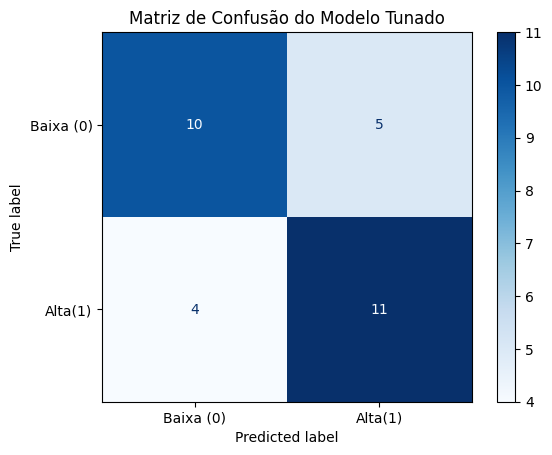

In [211]:
cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baixa (0)', 'Alta(1)'])
disp.plot
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão do Modelo Tunado')

### Observação final:

Decompus alguns projetos que foram entregues e o notebook no Vicky, com isso, tentei pegar as melhores práticas e conhecimentos que adiquiri nas aulas, pesquisas e os notebooks de sucesso. Alcancei uma acurácia de 70% mas acredito que dá para fazer melhorias.
Alguns estudos que tenho feito indicam que optar por uma variável **Target** tunada seria uma das melhores escolhas para uma precisão mais acertiva em mercado financeiro, porém nesse notebook optei por uma **Target** mais simples pois tive dificultades para acertar a construção de uma **Target** mais avançada, testes com uma **Target** mais avançada podem gerar melhores resultados.

